# HR 8799 - A real system of four giant exoplanets
Now you are going to use the simulation skills you have learnt in the previous two sections to model a real exoplanet system - HR 8799.

HR 8799 is a nearby star that is very young - it is 39 parcsec from Earth and is approximately 30 Myr old.  Since stars and planets form at the same time in a given system, the planets in this system are also very young, and thus still shine brightly from their heat of formation.  Because of this they can be directly imaged.  Four exoplanets have been imaged around the star HR 8799. The figure below shows the image from the SCWxAO/HiCIAO instrument on the 8m Subaru Telescope in Hawaii. Note that the light from the central star has been obscured by various optical methods in order to better show the four planets.  The white "plus" symbol shows the location of the central star, and the four planets (b,c,d,e) are circled.

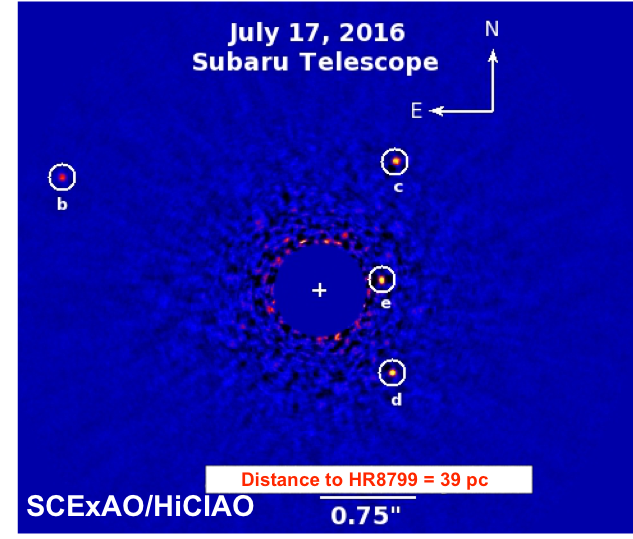

In [1]:
!pip install rebound
import rebound
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib notebook

sim = rebound.Simulation()
sim.units = ('yr', 'AU', 'kg')
sim.t = 0.0


##  Initial planet positions
To set up your `rebound` simulation you will need to first determine the starting positions of the four planets.  You should assume circular orbits to begin with ($e=0$).  You can work out the initial true anomoly ($f$) of each of the planets by measuring the angles of each of the planets relative to the central star.  To work out the semi-major axis ($a$) for each of the planets you will need to make measurements of the image and use the scale bar on the image (which shows 0.75 arc-seconds).  This will give you separations in arc-seconds.  You then need to convert arc-seconds to astronomical units (AU).  To do this you need to use the distance to the star (39 parsec), and the distance formula

$\alpha=a/d$,

where $\alpha$ is the angular separation in arc-seconds, $d$ is the distance to the star in parsecs, and $a$ is the planet star separation (i.e. the semi-major axis).  Enter in the planet position details into your simulation following the methods in the previous sections.

In [2]:
s_1=1
a_planet_b = s_1*86.9115
e_planet_b = 0.00
f_planet_b = 145.0

a_planet_c = s_1*46.3125
e_planet_c = 0.00
f_planet_c = 49.0

a_planet_d = s_1*33.7155
e_planet_d = 0.00
f_planet_d = 301.0

a_planet_e = s_1*19.227
e_planet_e = 0.00
f_planet_e = 0.0



## Star and Planet Masses
From the luminosity and spectral features of the central star, we know HR 8799 has a mass of 1.5 solar masses.  The masses of the four planets are trickier to determine, but we can estimate them using age-luminosity models of giant planets.  Giant planets cool as they get older, so their luminosity will decrease with time.  However if we know the age and luminosity, we can estimate their mass.  The table below shows the luminosities of each of the four planets in solar luminosties.

|Planet Name|Luminosity [log\,(L/L$_{\odot}$)]|
|-|-|
|HR 8799 b|-5.1|
|HR 8799 c|-4.7|
|HR 8799 d|-4.7|
|HR 8799 e|-4.7|

You need to estimate the masses for each of these planets using the set of models plotted below.  Each line in the plot is a "cooling track" for a different mass planet.  It shows the luminosity of the planet as a function of age.  The masses of each line are labelled on the right hand side in units of solar masses.  Remember the age of the star is 30Myr, and you can assume the planets are the same age.  Work out the mass for each of the planets, and then convert it to units of kilograms.

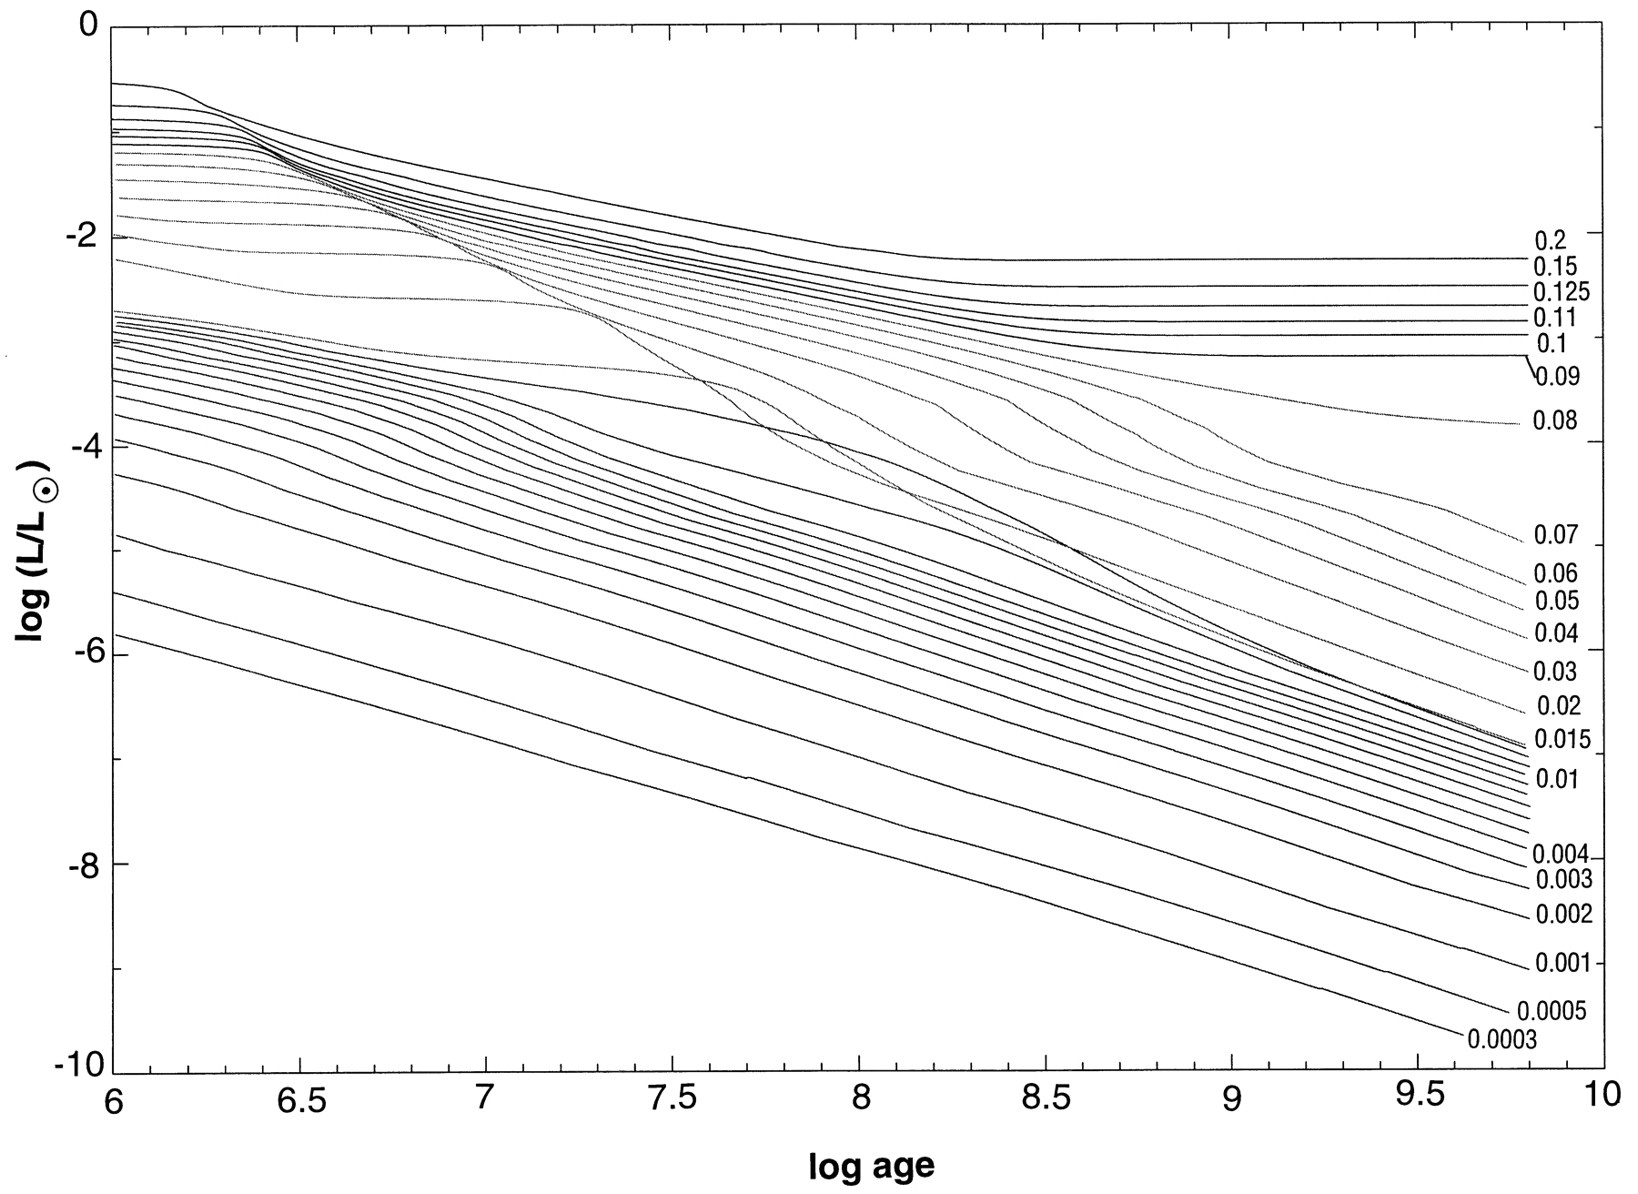

 Enter in the star and planet masses into your `rebound` simulation following the methods in the previous sections.

Once you have the masses, semi-major axes, and $f$ angles of the four planets you are ready to set up your `rebound` simulation. You may wish to make a plot of the planets orbits at the start of the simulation to check they appear similar to the Subaru image.

In [3]:
s=1
m_star = 1.5*1.989e30
m_planet_b = s*0.004*1.989e30
m_planet_c = s*0.007*1.989e30
m_planet_d = s*0.007*1.989e30
m_planet_e = s*0.007*1.989e30

sim.add(m=m_star, x=0, y=0, z=0, vx=0, vy=0 ,vz=0)
sim.add(m=m_planet_b,a=a_planet_b, e=e_planet_b, f=np.deg2rad(f_planet_b))
sim.add(m=m_planet_c,a=a_planet_c, e=e_planet_c, f=np.deg2rad(f_planet_c))
sim.add(m=m_planet_d,a=a_planet_d, e=e_planet_d, f=np.deg2rad(f_planet_d))
sim.add(m=m_planet_e,a=a_planet_e, e=e_planet_e, f=np.deg2rad(f_planet_e))

sim.move_to_com()



## Plot of the initial simulation
Once you have the simulation set up, make an orbit plot of the initial set up as you did in the previous sections.  The positions of the planets should look like the Subaru image of the system.

<IPython.core.display.Javascript object>


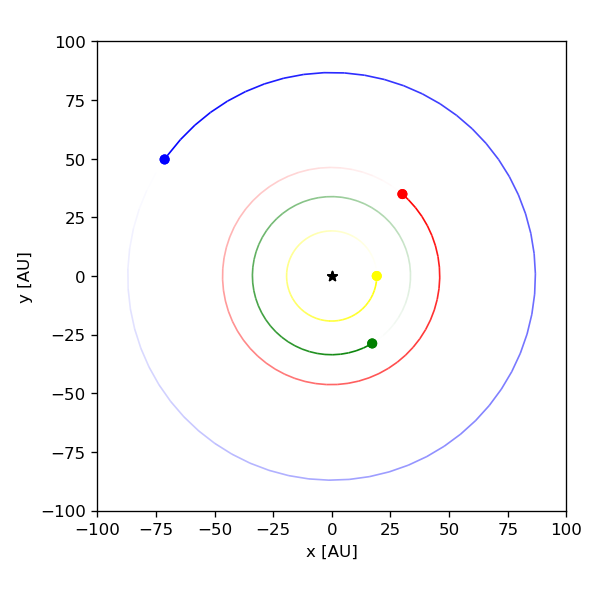

In [5]:
op = rebound.OrbitPlot(sim, orbit_style='trail', color=['blue','red','green','yellow'],
                            xlim=(-100,100), ylim=(-100,100), unitlabel='[AU]')
op.particles.set_color(['blue','red','green','yellow'])
op.fig.tight_layout()

## Testing the Stability of the System
To begin with you should run the simulation to check if it is stable. You can use the same method as you used for Neptune and Pluto, however we should just try a one thousand year simulation to begin with.  

As before, make a plot of the orbits at the end of the simulation to get an idea of whether the orbits changed. This doesn't tell us the whole story however, so also make a plot of the semi-major axes and eccentricities as a function of time.

Simulation completed in  3.884660823 seconds


<IPython.core.display.Javascript object>


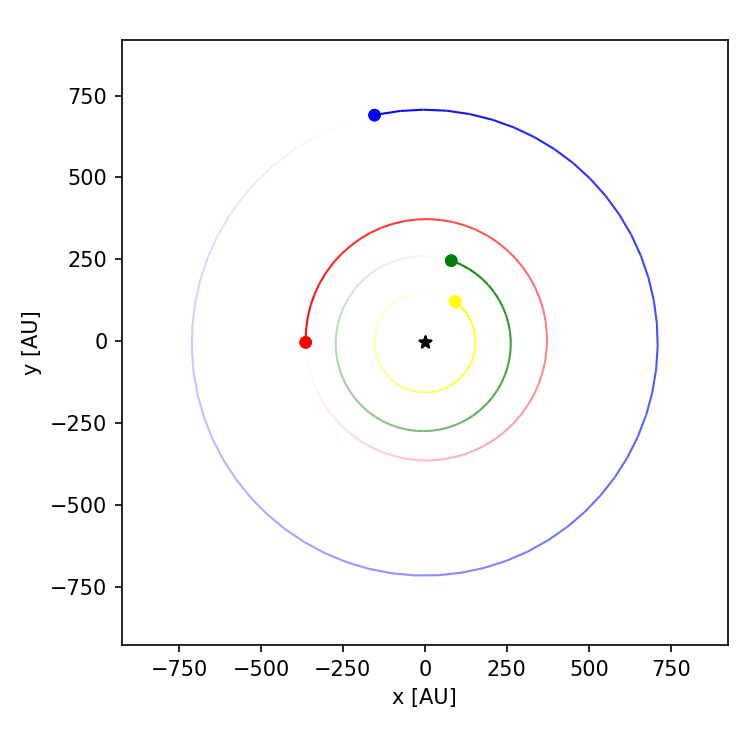

<IPython.core.display.Javascript object>


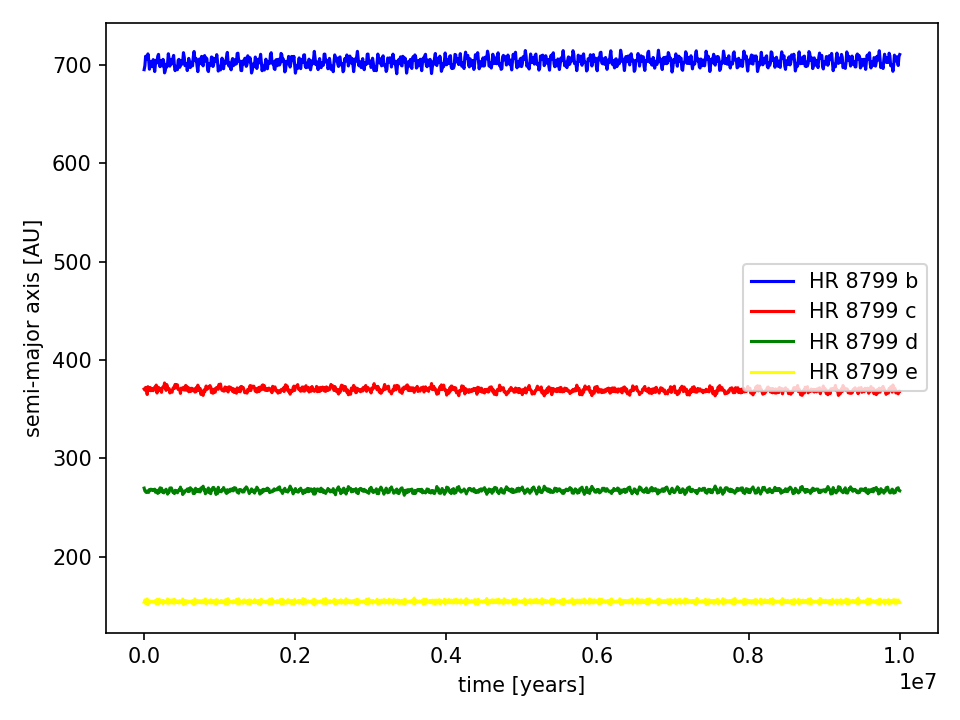

<IPython.core.display.Javascript object>


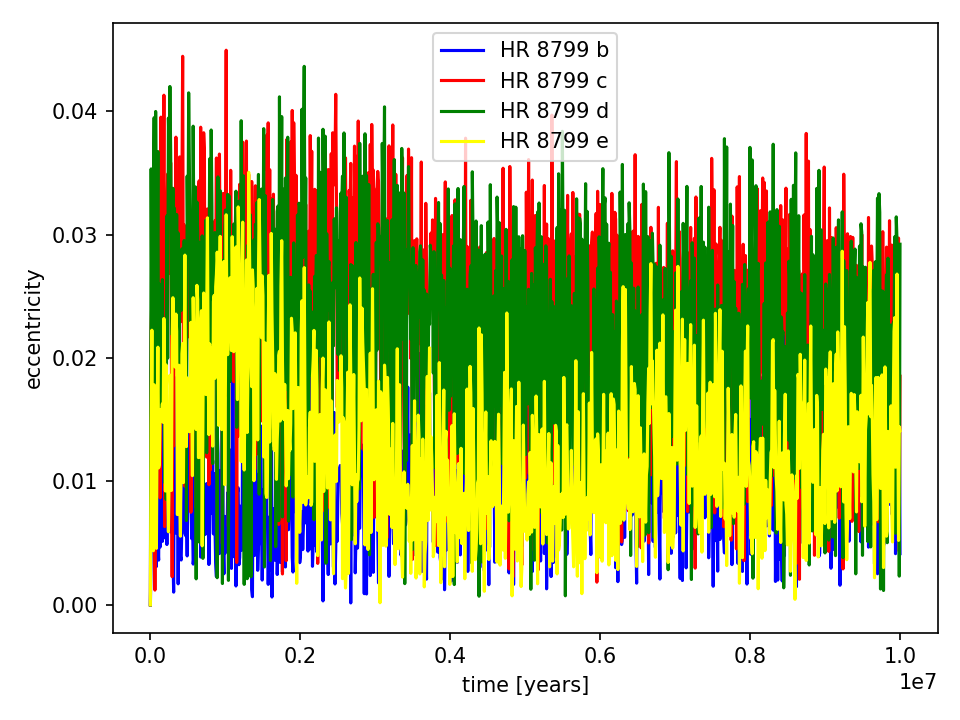

23.885089978253973
13.07527700404421
9.354506203981032
6.883840091183458
0.025728597552979213
0.04494086519912903
0.043633679015153665
0.035049847049989626


In [5]:
times = np.linspace(0, 1e7, 1000)

#Making the empty arrays in preparation for the simulation output
a_planetb_time = np.array([])
e_planetb_time = np.array([])
a_planetc_time = np.array([])
e_planetc_time = np.array([])
a_planetd_time = np.array([])
e_planetd_time = np.array([])
a_planete_time = np.array([])
e_planete_time = np.array([])

start_time = time.process_time() # Starting the compute timer

#Looping over the arry of times, and outputing the planet orbits at each timestep.
for t in times:
    sim.integrate(t)
    a_planetb_time = np.append(a_planetb_time, sim.particles[1].a )
    e_planetb_time = np.append(e_planetb_time, sim.particles[1].e )
    a_planetc_time = np.append(a_planetc_time, sim.particles[2].a )
    e_planetc_time = np.append(e_planetc_time, sim.particles[2].e )
    a_planetd_time = np.append(a_planetd_time, sim.particles[3].a )
    e_planetd_time = np.append(e_planetd_time, sim.particles[3].e )
    a_planete_time = np.append(a_planete_time, sim.particles[4].a )
    e_planete_time = np.append(e_planete_time, sim.particles[4].e )

print("Simulation completed in ",time.process_time() - start_time, "seconds") #Outputing the compute time.

op = rebound.OrbitPlot(sim, orbit_style='trail', color=['blue','red','green','yellow'], unitlabel='[AU]')
op.particles.set_color(['blue','red','green','yellow'])
op.fig.tight_layout()

fig, ax = plt.subplots()
ax.plot(times, a_planetb_time, color='blue', label='HR 8799 b')
ax.plot(times, a_planetc_time, color='red', label='HR 8799 c')
ax.plot(times, a_planetd_time, color='green', label='HR 8799 d')
ax.plot(times, a_planete_time, color='yellow', label='HR 8799 e')
ax.set_xlabel('time [years]')
ax.set_ylabel('semi-major axis [AU]')
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots()
ax.plot(times, e_planetb_time, color='blue', label='HR 8799 b')
ax.plot(times, e_planetc_time, color='red', label='HR 8799 c')
ax.plot(times, e_planetd_time, color='green', label='HR 8799 d')
ax.plot(times, e_planete_time, color='yellow', label='HR 8799 e')
ax.set_xlabel('time [years]')
ax.set_ylabel('eccentricity')
ax.legend()
fig.tight_layout()

print(np.max(a_planetb_time)-np.min(a_planetb_time))
print(np.max(a_planetc_time)-np.min(a_planetc_time))
print(np.max(a_planetd_time)-np.min(a_planetd_time))
print(np.max(a_planete_time)-np.min(a_planete_time))
print(np.max(e_planetb_time)-np.min(e_planetb_time))
print(np.max(e_planetc_time)-np.min(e_planetc_time))
print(np.max(e_planetd_time)-np.min(e_planetd_time))
print(np.max(e_planete_time)-np.min(e_planete_time))

## Massive problems?
For the first simulation, you have almost certainly found that even for a short simulation run, the system is unstable!  You will need to explore two possible reasons why.

### Planet masses
The first possibility is that the models for planet brightness as a function of age are systematically wrong, or that the age we assumed for the star is wrong. In either case, the result is that the planet masses could be much lower. We will however assume that the relative masses are correct, so go back and add a scale factor $s$ that each planet mass is multiplied by when the simulation is set up (e.g. something like `m_Planet_b=s*X*msun` where X is the mass you estimated). Now, run a series of simulations to figure out the highest value of this scale factor that you can use and have the simulation be stable for a million years.

There is no right answer for the factor $s$, and what you find could depend very sensitively on the specific semi-major axes and angles you derived from the figure. Given that the first simulation goes unstable very quickly, it's likely to be quite a lot smaller than 1.

There is no prize for the highest value of $s$, but you may find it interesting to compare with others.

### Planet semi-major axes
The second possibility is that planet masses are mostly correct, but that the semi-major axes are slightly wrong. While there is some uncertainty in measuring locations from the figure, another possibility is that the planet orbits aren't perfectly face on, so the radial values from the star you measure are not exact semi-major axes. Here you can try varying the semi-major axes a little to see if you can find orbits that are stable for a million years with more massive planets.

Again you can add a scale factor, this time for the semi-major axes.  Now the scale factor must be greater than unity.  Vary this scale factor, and determine the smallest scale factor that allows for stable orbits over 1 million years.

### Combining mass and semi-major axes changes
You can try combinations of scaled mass and scaled semi-major axis to find a system that has the scaling factors closest to unity.  Once you think you have a stable solution to the HR 8799 system you could try to run it for longer simulation times.  However remember to use what you learnt about compute time in the previous sections to make sure that your simulation does not take too long to finish!

## A Habitable World? (optional - if you have time)
Would it be possible for HR 8799 to host a habitable world?  You can run a simulation to test if such as world is plausible - at least in a dynamical sense.  

Firstly you will need to work out where to put the habitable planet in your simulation.  We normally think of "habitable" to mean the world could harbour liquid water, so you need to pick a planetary temperature accordingly.  Once you have a temperature, you can determine the distance to the star using the following expression:

T^4 = L_*/(16 pi sigma d^2)

where T is the temperature of the planet, L_* is the luminosity of the star, sigma is the Stefan-Boltzmann constant, and d is the distance between the planet and the star.


You can assign a mass, eccentricity and initial true anomoly to your planet.  Just pick what you think are reasonable quantities for these parameters.  Then start your simulation, and monitor the habitable planet.  Is it stable over time?  Does the semi-major axis vary?  Any variation in the semi-major axis would result in temperature changes for the planet, so you should quantify those and consider if they would be harmful for any potential life on the planet.  